# Notebook 1 – Model Performance Analysis



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)

feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]
X = df[feature_cols]
y = df["IsCancelled"]
print(f"Rows: {len(df):,}   Cancellation rate: {y.mean():.4f}")
df.head()

Rows: 539,392   Cancellation rate: 0.0172


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0


## Setting Up: Training, Validation, and Test Performance

Every model in this notebook is evaluated on **three** separate slices of
data, and it's essential not to mix these up:

* **Training Performance** — how well the model does on the exact data
  it was fit on. Always the most optimistic number; on its own it says
  almost nothing about real-world performance.
* **Validation Performance** — how well the model does on a held-out
  slice used *during development*, to make decisions like which
  hyperparameters to use. This is the score to watch while tuning.
* **Test Performance** — how well the model does on a final slice that's
  touched only once, after every decision has already been made. This is
  the honest, final estimate of how the model will perform in the real
  world.

The three-way split below is used throughout this notebook.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train):,}   Validation: {len(X_val):,}   Test: {len(X_test):,}")

demo_model = LogisticRegression(max_iter=1000, class_weight="balanced")
demo_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, demo_model.predict(X_train))
val_acc = accuracy_score(y_val, demo_model.predict(X_val))
test_acc = accuracy_score(y_test, demo_model.predict(X_test))

print(f"\nTraining accuracy:   {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy:       {test_acc:.4f}")
print("\nAll three land close together here -- a first, simple sign that this particular")
print("model isn't overfitting badly (more rigorous diagnostics follow below).")

Train: 323,635   Validation: 107,878   Test: 107,879

Training accuracy:   0.7990
Validation accuracy: 0.8001
Test accuracy:       0.7994

All three land close together here -- a first, simple sign that this particular
model isn't overfitting badly (more rigorous diagnostics follow below).


## Generalization

**What it is:** a model's ability to perform well on *new* data it has
never seen, not just the data it was trained on. Generalization is the
entire point of building a model in the first place — a model that only
works on its own training data is useless in production, where every
future customer, order, or transaction is by definition something it
hasn't seen before.

Training performance alone can never measure generalization (the model
has already seen that exact data); only validation and test performance,
computed on genuinely held-out rows, actually measure it. Every
technique in the rest of this notebook is, in one way or another, a tool
for checking or improving generalization.

## Underfitting

**What it is:** the model is too simple to capture the real pattern in
the data, so it performs poorly *even on the training data itself*.

**Demonstration:** an intentionally under-powered model — Logistic
Regression restricted to a single, weak feature (`Month`, which EDA in
earlier notebooks showed has almost no relationship with cancellation) —
is compared against the full-featured model above.

In [5]:
underfit_model = LogisticRegression(max_iter=1000, class_weight="balanced")
underfit_model.fit(X_train[["Month"]], y_train)

underfit_train_acc = accuracy_score(y_train, underfit_model.predict(X_train[["Month"]]))
underfit_val_acc = accuracy_score(y_val, underfit_model.predict(X_val[["Month"]]))

print(f"Underfit model (1 weak feature) -- Train: {underfit_train_acc:.4f}   Val: {underfit_val_acc:.4f}")
print(f"Full-featured model             -- Train: {train_acc:.4f}   Val: {val_acc:.4f}")
print("\nThe underfit model's training accuracy is noticeably worse than the full model's --")
print("it's failing on data it has already seen, the hallmark of underfitting.")

Underfit model (1 weak feature) -- Train: 0.5518   Val: 0.5505
Full-featured model             -- Train: 0.7990   Val: 0.8001

The underfit model's training accuracy is noticeably worse than the full model's --
it's failing on data it has already seen, the hallmark of underfitting.


## Overfitting

**What it is:** the model is too complex relative to the data, so it
starts fitting noise specific to the training set rather than the true
underlying pattern. Its training performance keeps looking better and
better, but performance on new data does not follow — or gets worse.

**Demonstration:** an unrestricted Decision Tree (allowed to grow as deep
as it wants) is compared against a shallow one — using **F1 score**
rather than accuracy, since `IsCancelled` is heavily imbalanced and (per
Notebook 14) accuracy alone can hide a lot of overfitting behind a
majority class that's easy to predict correctly either way.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

shallow_tree = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
shallow_tree.fit(X_train, y_train)

deep_tree = DecisionTreeClassifier(class_weight="balanced", random_state=42)  # no depth limit
deep_tree.fit(X_train, y_train)

for name, model in [("Shallow Tree (max_depth=4)", shallow_tree), ("Unrestricted Tree", deep_tree)]:
    tr = f1_score(y_train, model.predict(X_train))
    va = f1_score(y_val, model.predict(X_val))
    print(f"{name:28s} Train F1: {tr:.4f}   Val F1: {va:.4f}   Gap: {tr - va:.4f}   Depth: {model.get_depth()}")

Shallow Tree (max_depth=4)   Train F1: 0.0508   Val F1: 0.0490   Gap: 0.0018   Depth: 4
Unrestricted Tree            Train F1: 0.1147   Val F1: 0.0693   Gap: 0.0454   Depth: 32


The unrestricted tree's training F1 climbs meaningfully higher than the
shallow tree's, while its validation F1 barely improves in comparison —
the gap between the two is roughly 25x larger for the unrestricted tree
than for the shallow one. That widening, one-sided **gap** between
training and validation performance is the clearest fingerprint of
overfitting — and this comparison also shows why the *metric* used to
look for that gap matters: plain accuracy (try it yourself) barely moves
between these two models at all, since it's dominated by the easy
majority class, and would have hidden this same overfitting almost
entirely.

## Bias

**What it is:** error that comes from a model's own assumptions being
too rigid or too simple to represent the true relationship in the data,
regardless of how much training data it's given. High bias is the root
*cause* of underfitting — a model with high bias will keep making the
same kind of systematic mistake even as more data is added, because the
problem is the model's limited structure, not a lack of examples.

## Variance

**What it is:** error that comes from a model being overly sensitive to
the specific training data it happened to see, so that small changes in
which rows were sampled produce noticeably different fitted models.
High variance is the root *cause* of overfitting — a high-variance model
essentially memorizes quirks of its particular training sample rather
than learning the shared, stable pattern underneath.

**Demonstration:** this specific effect is easiest to see cleanly on a
small, controlled dataset rather than this notebook's full ~540,000-row
dataset — with that much real data, any reasonably-sized bootstrap
resample is still huge, so both a shallow and a deep tree end up seeing
practically the same data every time and look artificially stable. A
small synthetic two-class dataset (300 points) makes the effect visible:
a shallow and an unrestricted tree are each refit on several different
bootstrap resamples of the same small training set, and their accuracy
on a fixed validation set is compared.

In [7]:
from sklearn.datasets import make_moons

X_small, y_small = make_moons(n_samples=300, noise=0.3, random_state=42)
X_small_train, y_small_train = X_small[:150], y_small[:150]
X_small_val, y_small_val = X_small[150:], y_small[150:]

shallow_val_scores, deep_val_scores = [], []
for seed in range(8):
    rng = np.random.default_rng(seed)
    boot_idx = rng.choice(len(X_small_train), size=len(X_small_train), replace=True)  # bootstrap resample

    s_tree = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_small_train[boot_idx], y_small_train[boot_idx])
    d_tree = DecisionTreeClassifier(random_state=42).fit(X_small_train[boot_idx], y_small_train[boot_idx])

    shallow_val_scores.append(accuracy_score(y_small_val, s_tree.predict(X_small_val)))
    deep_val_scores.append(accuracy_score(y_small_val, d_tree.predict(X_small_val)))

print("Shallow tree (max_depth=2) validation accuracy across 8 bootstrap resamples:")
print(np.round(shallow_val_scores, 4), " -> std:", round(np.std(shallow_val_scores), 4))
print("\nUnrestricted tree validation accuracy across the SAME 8 resamples:")
print(np.round(deep_val_scores, 4), " -> std:", round(np.std(deep_val_scores), 4))

Shallow tree (max_depth=2) validation accuracy across 8 bootstrap resamples:
[0.84   0.8533 0.8533 0.8533 0.8467 0.8467 0.8133 0.8333]  -> std: 0.0129

Unrestricted tree validation accuracy across the SAME 8 resamples:
[0.8267 0.8267 0.8133 0.8733 0.8267 0.8533 0.8    0.8533]  -> std: 0.0225


The unrestricted tree's validation accuracy swings around noticeably
more from one resample to the next (a higher standard deviation) than
the shallow tree's — that instability *is* variance, and it's a direct
consequence of the model being complex enough to fit each resample's
individual noise rather than a stable, shared pattern. (This is also
exactly why the earlier "Overfitting" demonstration relied on the full
real dataset's train/validation *gap* rather than resampling — on a
dataset this large, that gap is still the reliable overfitting signal,
but resampling-based variance needs a small dataset to show up this
clearly.)

## Bias-Variance Tradeoff

**What it is:** bias and variance move in opposite directions as model
complexity changes. A very simple model has high bias but low variance
(consistently wrong, but consistently so). A very complex model has low
bias but high variance (capable of representing the true pattern, but
unstable and easily thrown off by noise). Total error is minimized
somewhere in the *middle*, not at either extreme — finding that middle
ground is the practical goal of model selection.

Below, this tradeoff is traced directly on the real data by sweeping a
Decision Tree's `max_depth` and recording both training and validation
accuracy at each setting.

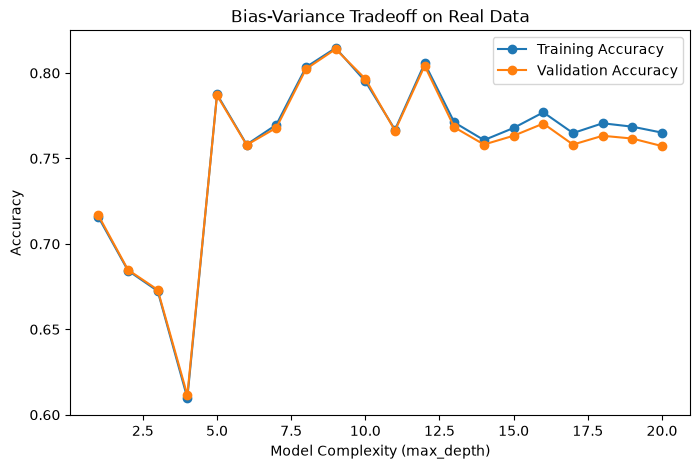

max_depth with the best validation accuracy: 9


In [8]:
depths = range(1, 21)
train_accs, val_accs = [], []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    val_accs.append(accuracy_score(y_val, tree.predict(X_val)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs, marker="o", label="Training Accuracy")
plt.plot(depths, val_accs, marker="o", label="Validation Accuracy")
plt.xlabel("Model Complexity (max_depth)")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Tradeoff on Real Data")
plt.legend()
plt.show()

best_depth = list(depths)[int(np.argmax(val_accs))]
print("max_depth with the best validation accuracy:", best_depth)

Training accuracy keeps climbing as depth increases (a deeper tree can
always fit its own training data at least as well). Validation accuracy
rises at first — as bias drops and the tree starts capturing real
structure — then flattens or declines as depth keeps growing and
variance takes over. The best depth sits where validation accuracy peaks,
not where training accuracy is highest.

## Learning Curves

**What they are:** a plot of training score and validation score as a
*function of how much training data* the model was given, from a small
slice up to the full training set. Learning curves answer a different
question than the complexity sweep above: *"would this model benefit
from more data?"* — rather than *"is this model too simple or too
complex?"*

**How to read the characteristic shapes:**
* **Underfitting:** both curves converge to a low score fairly quickly,
  and stay close together — more data doesn't help, because the model
  itself isn't capable of representing the pattern.
* **Overfitting:** a persistent, large gap remains between a high
  training score and a lower validation score even as more data is
  added — though the gap typically *narrows* as data grows, since it
  gets harder for a fixed-complexity model to memorize an ever-larger
  training set.
* **Good fit:** the two curves converge to a similarly high score.

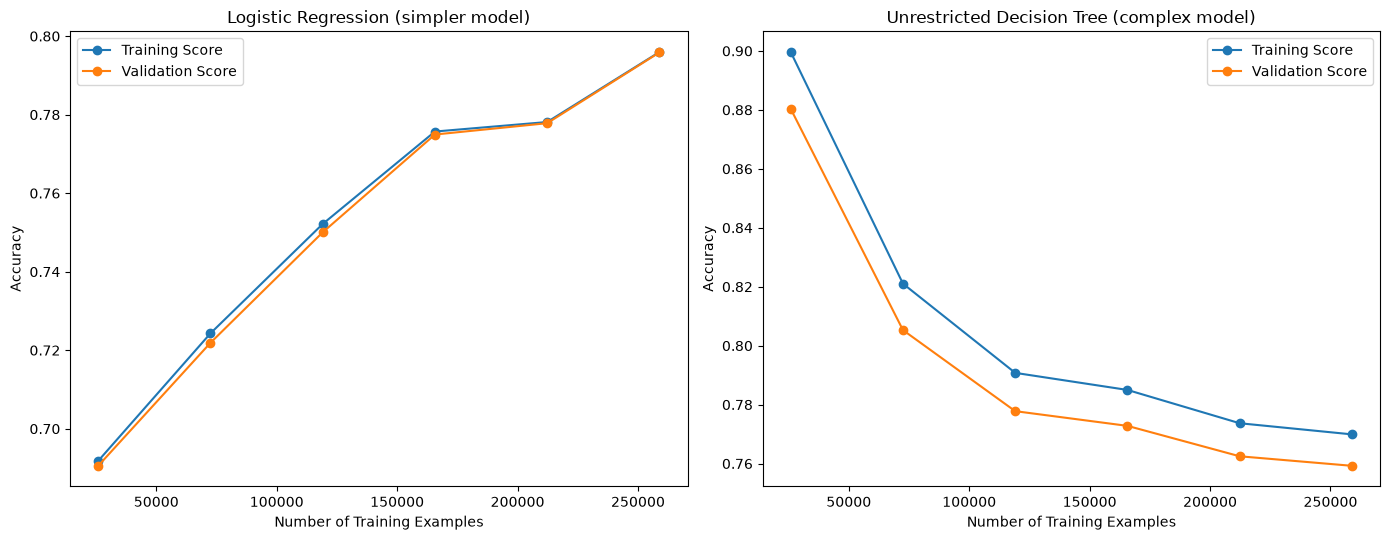

In [9]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, model, title in [
    (axes[0], LogisticRegression(max_iter=1000, class_weight="balanced"), "Logistic Regression (simpler model)"),
    (axes[1], DecisionTreeClassifier(class_weight="balanced", random_state=42), "Unrestricted Decision Tree (complex model)"),
]:
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1,
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training Score")
    ax.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Score")
    ax.set_xlabel("Number of Training Examples")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

The Logistic Regression curves converge close together (a fairly
simple, stable model for this feature set), while the unrestricted
Decision Tree keeps a visible gap between a near-perfect training score
and a lower validation score across every training size shown — the
textbook overfitting shape.

## Validation Curves

**What they are:** a plot of training score and validation score as a
*function of a single hyperparameter's value*, with the training set
size held fixed. Where a learning curve asks "does more data help?", a
validation curve asks "what happens as I make this specific setting more
or less aggressive?" — directly showing where a hyperparameter starts
trading useful bias reduction for harmful variance increase.

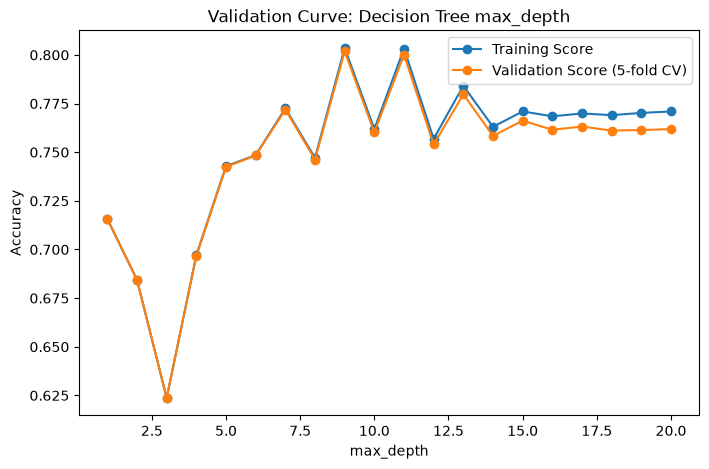

In [10]:
from sklearn.model_selection import validation_curve

depth_range = range(1, 21)
train_scores_vc, val_scores_vc = validation_curve(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    X_train, y_train,
    param_name="max_depth", param_range=depth_range,
    cv=5, scoring="accuracy", n_jobs=-1,
)

plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_scores_vc.mean(axis=1), marker="o", label="Training Score")
plt.plot(depth_range, val_scores_vc.mean(axis=1), marker="o", label="Validation Score (5-fold CV)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Validation Curve: Decision Tree max_depth")
plt.legend()
plt.show()

This looks similar to the "Bias-Variance Tradeoff" plot earlier in this
notebook, and it is the same underlying idea — but a validation curve
specifically uses cross-validation (multiple folds averaged) for its
validation score rather than a single held-out slice, making it a more
stable, less luck-dependent version of the same diagnostic (tying
directly back to Notebook 16's Cross Validation).

## Model Complexity

**What it is:** the general capacity of a model to represent intricate
patterns — a polynomial's degree, a tree's `max_depth`, the number of
trees in a forest, and so on are all, in different ways, knobs
controlling complexity. Every plot in this notebook has really told the
same underlying story: turning complexity up always helps *training*
performance, but only helps *validation/test* performance up to a point,
after which it starts hurting it. Deliberately controlling complexity —
rather than just maximizing model power — is the practical core of
managing the bias-variance tradeoff.

## How to Identify Whether a Model Is Underfitting or Overfitting

Bringing every tool in this notebook together into a practical checklist:

**1. Look at the train/validation gap directly.**
* Both scores low, and close together → **underfitting.**
* Training score high, validation score noticeably lower (a large gap)
  → **overfitting.**
* Both scores high and close together → **good fit.**

**2. Check the learning curve shape (score vs. training set size).**
* Both curves converge quickly to a low score, and more data doesn't
  close the gap → **underfitting** — the model itself needs more
  capacity, not more data.
* A persistent, large gap between a high training curve and a lower
  validation curve, even with plenty of data → **overfitting** — the
  model needs to be simplified, regularized, or given more data if
  more is available.

**3. Check the validation curve shape (score vs. complexity/hyperparameter).**
* Both training and validation score are low at the current setting,
  and increasing complexity improves *both* → currently **underfit**;
  the hyperparameter can be pushed further.
* Validation score has already peaked and started declining while
  training score keeps climbing → currently **overfit**; the
  hyperparameter has been pushed too far.

**4. Match the pattern to its root cause.**
* Underfitting is a **high bias** problem → fix it with a more
  expressive model, more/better features, or less regularization.
* Overfitting is a **high variance** problem → fix it with a simpler
  model, more training data, regularization (Notebook 15), or ensembling
  (Notebook 9).

In short: **underfitting shows up as poor performance everywhere,
including on the training data; overfitting shows up as a gap** — great
performance where the model has already seen the answer, and
meaningfully worse performance where it hasn't. Every diagnostic in this
notebook (train/val comparison, learning curves, validation curves) is,
at its core, just a different way of exposing that same gap.